# MAIE5532 Assignment 2 — Key Results Demo

**Student: Luo Xiaoyu**

Run this notebook from the submission root using the **Python (maie5532)** kernel. Select **Run All**, then save to retain the output tables and figures. No training is performed. Sections 1–5 load saved experiments; Section 6 performs one-image inference. CIFAR-10 is downloaded if not cached. All figures and outputs populate automatically; no manual screenshots are needed.

## 1. Load saved results

In [3]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Run from the submission root without machine-specific absolute paths.
ROOT = Path.cwd()
if not (ROOT / "part1").is_dir():
    raise FileNotFoundError("Start the notebook from the MAIE5532_Assignment2_LuoXiaoyu root directory.")

def read_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def show_table(headers, rows):
    # Display Markdown tables directly without adding a pandas dependency.
    lines = ["| " + " | ".join(headers) + " |",
             "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(str(v) for v in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

baseline = read_json("part1/part1_results/baseline_metrics.json")
cloud = read_json("part2/part2_results/cloud_optimization_report.json")["results"]
edge = read_json("part3/part3_results/edge_optimization_report.json")
pipeline = read_json("part4/part4_results/multi_scale_optimization_report.json")
print("Loaded saved results for Parts 1–4.")


Loaded saved results for Parts 1–4.


## 2. Baseline
The model must exceed 70% test accuracy. Weight memory excludes activations and runtime overhead; the Keras archive includes optimizer state.

| Metric | Result |
| --- | --- |
| Test accuracy | 87.71% |
| Requirement (>70%) | True |
| Parameters | 324,394 |
| Weight memory (MiB) | 1.237 |
| Keras archive (MiB) | 3.809 |
| Training time (s) | 172.35 |
| Mean GPU latency (ms) | 1.004 |

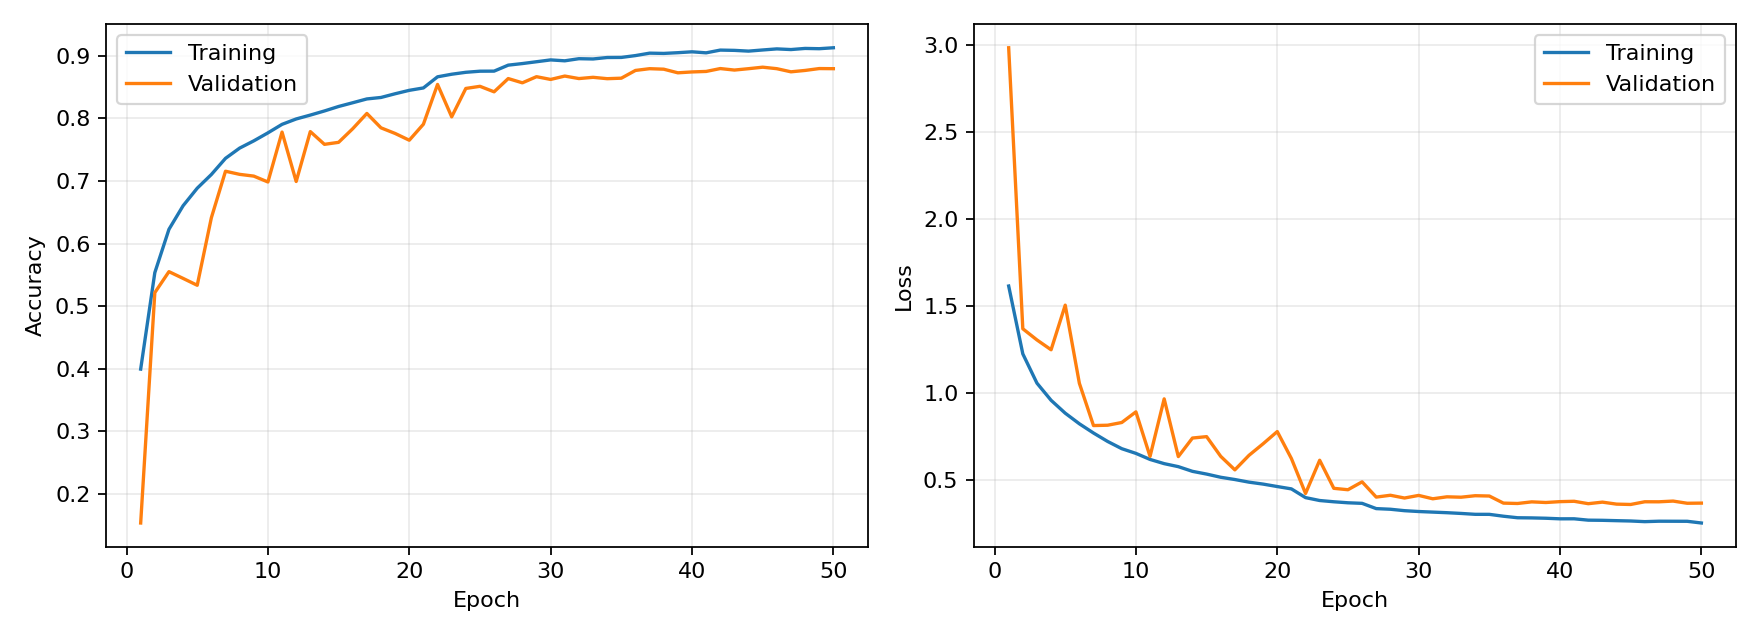

In [4]:
show_table(["Metric", "Result"], [
    ["Test accuracy", f"{baseline['test_accuracy']:.2%}"],
    ["Requirement (>70%)", baseline["accuracy_requirement_met"]],
    ["Parameters", f"{baseline['parameters']:,}"],
    ["Weight memory (MiB)", f"{baseline['weight_memory_mib']:.3f}"],
    ["Keras archive (MiB)", f"{baseline['model_size_mib']:.3f}"],
    ["Training time (s)", f"{baseline['training_seconds']:.2f}"],
    ["Mean GPU latency (ms)", f"{baseline['inference']['mean_ms']:.3f}"],
])
display(Image(filename=str(ROOT / "part1/part1_results/training_curves.png")))


## 3. Cloud optimization
Compare accuracy, training time, and training throughput. The two logical replicas share one physical GPU; their scaling is a simulation.

| Configuration | Accuracy | Training (s) | Training images/s |
| --- | --- | --- | --- |
| fp32 | 87.35% | 141.74 | 17,690.1 |
| mixed | 87.51% | 241.56 | 9,892.7 |
| distributed_one | 87.50% | 156.40 | 16,702.8 |
| distributed_two | 87.55% | 547.48 | 4,452.4 |
| pipeline_serial | 87.60% | 140.90 | 17,778.0 |
| batch256 | 86.42% | 104.63 | 25,285.4 |
| accumulation | 87.55% | 307.73 | 7,688.3 |
| teacher | 88.55% | 170.78 | 14,474.1 |
| distilled | 87.86% | 160.31 | 15,451.0 |

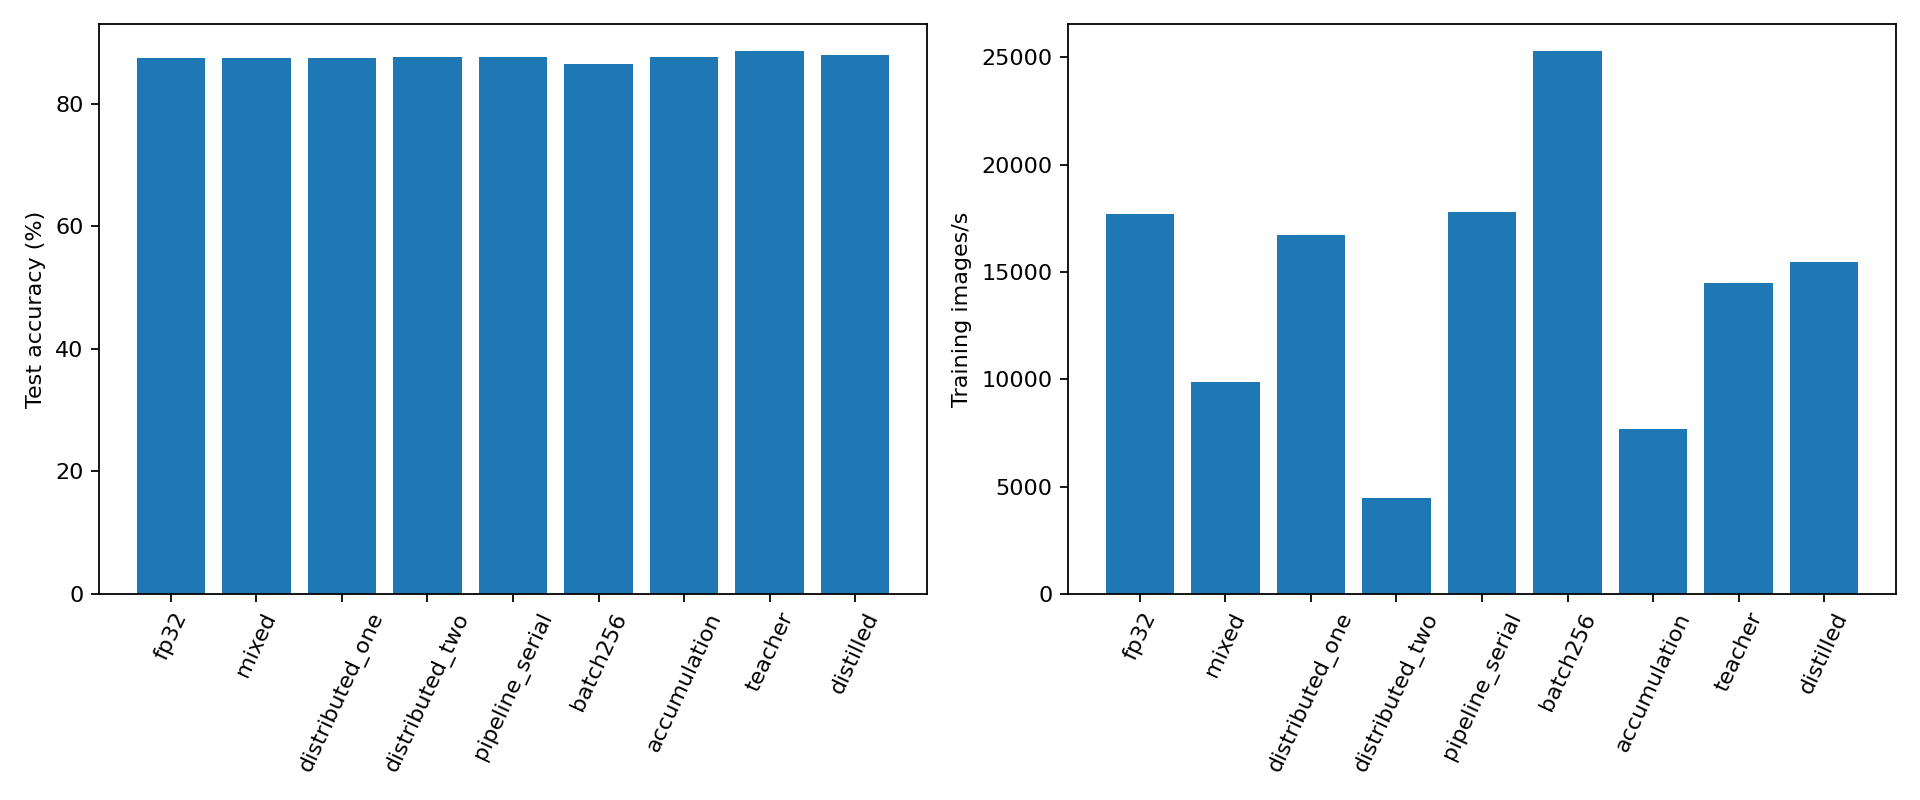

Simulated two-replica efficiency: 13.33%
Batch-256 throughput ratio: 1.429
Distillation accuracy gain (percentage points): 0.51


In [5]:
show_table(["Configuration", "Accuracy", "Training (s)", "Training images/s"], [
    [name, f"{m['test_accuracy']:.2%}", f"{m['training_seconds']:.2f}",
     f"{m['train_images_per_second']:,.1f}"] for name, m in cloud.items()
])
display(Image(filename=str(ROOT / "part2/part2_results/performance_comparison.png")))
ratio = cloud["distributed_two"]["train_images_per_second"] / cloud["distributed_one"]["train_images_per_second"]
print(f"Simulated two-replica efficiency: {ratio / 2:.2%}")
print("Batch-256 throughput ratio:",
      round(cloud["batch256"]["train_images_per_second"] / cloud["fp32"]["train_images_per_second"], 3))
print("Distillation accuracy gain (percentage points):",
      round(100 * (cloud["distilled"]["test_accuracy"] - cloud["fp32"]["test_accuracy"]), 2))


Larger batches improved training throughput. Mixed precision saved memory but increased training time. Distillation improved student accuracy without increasing parameter count. Training throughput is not inference throughput.

## 4. Edge optimization
Compare the Part 3 TFLite exports. Latency is measured on the local single-thread CPU, not an edge board. Recorded sparsity counts zeros across all stored weights, including biases and BatchNorm state.

In [6]:
edge_models = {"baseline_float32": edge["baseline"]["tflite"],
               **edge["quantization"], **edge["tflite_conversions"]}
show_table(["TFLite model", "Accuracy", "Size (MiB)", "CPU latency (ms)"], [
    [name, f"{m['accuracy']:.2%}", f"{m['size_mib']:.3f}", f"{m['latency_mean_ms']:.3f}"]
    for name, m in edge_models.items()
])
show_table(["Pruning model", "Recorded zero ratio", "Parameters"], [
    [name, f"{m['actual_sparsity']:.2%}", f"{m['parameters']:,}"]
    for name, m in edge["pruning"].items()
])
# Plot saved metrics without rerunning experiments.
fig, ax = plt.subplots(figsize=(9, 4))
for name, m in edge_models.items():
    ax.scatter(m["size_mib"], m["accuracy"] * 100)
    ax.annotate(name, (m["size_mib"], m["accuracy"] * 100),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set(xlabel="TFLite size (MiB)", ylabel="Test accuracy (%)",
       title="Edge accuracy–size trade-off", xscale="log")
ax.margins(x=0.35, y=0.2)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


| TFLite model | Accuracy | Size (MiB) | CPU latency (ms) |
| --- | --- | --- | --- |
| baseline_float32 | 87.71% | 1.238 | 0.382 |
| dynamic_range | 87.67% | 0.324 | 0.319 |
| int8 | 87.39% | 0.328 | 0.333 |
| float16 | 87.72% | 0.625 | 0.367 |
| pruned_50 | 87.65% | 1.238 | 0.378 |
| pruned_75 | 84.57% | 1.238 | 0.407 |
| architecture_optimized | 70.54% | 0.065 | 0.039 |
| nas_best | 67.96% | 0.141 | 0.097 |

| Pruning model | Recorded zero ratio | Parameters |
| --- | --- | --- |
| pruned_50 | 49.61% | 324,394 |
| pruned_75 | 74.42% | 324,394 |

<Figure size 900x400 with 1 Axes>

In [7]:
# Compute the accuracy-parameter Pareto frontier from the search results.
search = edge["nas_search"]
rows = []
for c in search:
    dominated = any(
        o["parameters"] <= c["parameters"]
        and o["validation_accuracy"] >= c["validation_accuracy"]
        and (o["parameters"] < c["parameters"]
             or o["validation_accuracy"] > c["validation_accuracy"])
        for o in search)
    rows.append([c["depth"], c["width_multiplier"], c["kernel_size"],
                 c["parameters"], f"{c['validation_accuracy']:.2%}",
                 "No" if dominated else "Yes"])
show_table(["Depth", "Width", "Kernel", "Parameters", "Validation accuracy", "Pareto"], rows)


| Depth | Width | Kernel | Parameters | Validation accuracy | Pareto |
| --- | --- | --- | --- | --- | --- |
| 2 | 0.5 | 3 | 5589 | 50.48% | Yes |
| 2 | 0.5 | 5 | 6661 | 45.58% | No |
| 2 | 0.75 | 3 | 11245 | 53.40% | Yes |
| 2 | 0.75 | 5 | 12829 | 57.98% | Yes |
| 3 | 0.5 | 3 | 15157 | 57.34% | No |
| 3 | 0.5 | 5 | 17765 | 55.22% | No |
| 3 | 0.75 | 3 | 31741 | 61.20% | Yes |
| 3 | 0.75 | 5 | 35629 | 62.10% | Yes |

Quantization reduced storage while preserving most baseline accuracy. Pruning did not shrink dense TFLite files. Lightweight models were much smaller but less accurate. The frontier labels above are derived from saved results; the training program selected by its weighted score. The selected NAS model did not outperform the fixed lightweight model after final training.

## 5. Multi-scale deployment
Cloud selection prioritizes training throughput, edge selection uses validation accuracy, and microcontroller selection prioritizes file size. The final edge and microcontroller evaluations use all 10,000 test images.

In [8]:
final_results = pipeline["optimization_results"]
show_table(["Target", "Strategy", "Accuracy", "Size (MiB)", "Local latency (ms)"], [
    [name, m["optimization_strategy"], f"{m['accuracy']:.2%}",
     f"{m['model_size_mb']:.4f}", f"{m['estimated_latency_ms']:.3f}"]
    for name, m in final_results.items()
])
checks = pipeline["scaling_analysis"]["constraint_checks"]
show_table(["Target", "File budget met", "Local latency budget met",
            "Target latency / memory / power"], [
    [name, m["model_storage_met"], m["local_reference_latency_met"], "Not measured"]
    for name, m in checks.items()
])
print("Accuracy–size Pareto frontier:",
      ", ".join(pipeline["scaling_analysis"]["accuracy_size_pareto_frontier"]))


| Target | Strategy | Accuracy | Size (MiB) | Local latency (ms) |
| --- | --- | --- | --- | --- |
| cloud_server | Reused cloud configuration: batch256 | 86.42% | 1.3142 | 0.860 |
| edge_device | dynamic_range | 87.67% | 0.3242 | 0.310 |
| microcontroller | architecture_optimized_int8 | 70.53% | 0.0346 | 0.049 |

| Target | File budget met | Local latency budget met | Target latency / memory / power |
| --- | --- | --- | --- |
| cloud_server | True | True | Not measured |
| edge_device | True | True | Not measured |
| microcontroller | True | True | Not measured |

Accuracy–size Pareto frontier: edge_device, microcontroller


The edge model balances accuracy and storage. The lightweight INT8 model is smallest but has lower accuracy. GPU and CPU latencies are not direct cross-device speed comparisons. Actual target memory and power remain unverified.

For real-time video, use edge inference with cloud backup, subject to complete pipeline latency testing. For an IoT network, the TinyML model is a starting point; the below-1-mW requirement is unverified. For mobile applications, use local quantized inference with model choice adapted to available resources.

## 6. Example inference for TFLite deployment targets
Run these cells to classify one CIFAR-10 test image with the edge and microcontroller TFLite models. Change **SAMPLE_INDEX** (0–9999) to see another example. The image and predictions appear below automatically. This demonstrates deployment-model loading and inference, not a replacement for the full test-set benchmark.

170498071/170498071 [==============================] - 2173s 13us/step


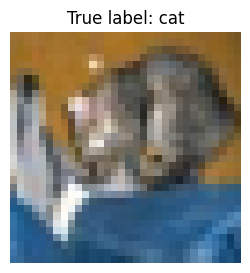

In [9]:
import tensorflow as tf

# Allocate GPU memory as needed; retain the configuration if already initialized.
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

SAMPLE_INDEX = 0  # Change to any index from 0 to 9999.
(_, _), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]
image = test_images[SAMPLE_INDEX].astype(np.float32) / 255.0
true_label = int(test_labels[SAMPLE_INDEX, 0])
plt.figure(figsize=(3, 3))
plt.imshow(test_images[SAMPLE_INDEX])
plt.title(f"True label: {class_names[true_label]}")
plt.axis("off")
plt.show()


In [13]:
def predict_tflite(path, image):
    # Use quantization parameters to process integer model inputs and outputs.
    interpreter = tf.lite.Interpreter(model_path=str(path), num_threads=1)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]
    value = image[None, ...]
    if np.issubdtype(inp["dtype"], np.integer):
        scale, zero = inp["quantization"]
        limits = np.iinfo(inp["dtype"])
        value = np.clip(np.round(value / scale + zero), limits.min, limits.max)
    interpreter.set_tensor(inp["index"], value.astype(inp["dtype"]))
    interpreter.invoke()
    output = interpreter.get_tensor(out["index"])
    if np.issubdtype(out["dtype"], np.integer):
        scale, zero = out["quantization"]
        output = (output.astype(np.float32) - zero) * scale
    return output[0]

model_dir = ROOT / "part4/part4_results/optimized_models"
predictions = {
    "edge_device": predict_tflite(model_dir / "edge_device.tflite", image),
    "microcontroller": predict_tflite(model_dir / "microcontroller.tflite", image),
}
show_table(["Target", "Prediction", "True label", "Correct"], [
    [target, class_names[int(np.argmax(scores))], class_names[true_label],
     int(np.argmax(scores)) == true_label]
    for target, scores in predictions.items()
])


| Target | Prediction | True label | Correct |
| --- | --- | --- | --- |
| edge_device | cat | cat | True |
| microcontroller | cat | cat | True |

## 7. Written analysis
See [multi_scale_analysis.pdf](part5/multi_scale_analysis.pdf) for the full analysis. Save this notebook after execution to retain tables, figures, and example predictions. A model may misclassify an individual image even when the demo runs successfully.